# Regime Detection and Adaptive Trading 📈📊💱
 **Proyecto:** Detección de Régimen y Trading Adaptativo  

 **Autor:** Francisco Encina  

 **Profesor:** Nicolás Torres

 **Curso:** Aprendizaje de Máquinas - IPD440

 **Universidad Técnica Federico Santa María**

---

## 📋 Estructura del Proyecto

1. **Data Extraction & Feature Engineering**
2. **Regime Detection (HMM)**
3. **ML Models por Régimen**
4. **Trading Strategy & Backtesting**

*This notebook contains: Trading Strategy & Backtesting*

*Objetivo: Convertir predicciones ML en estrategias de trading y evaluar performance*

**Estrategias a comparar:**
 1. Buy & Hold (baseline fundamental)
 2. Baseline ML Strategy (modelo genérico)
 3. Adaptive Strategy (sistema adaptativo por régimen)


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 4.1 Cargar Datos con Predicciones

In [2]:
# Cargar predicciones del Step 3
df_test = pd.read_csv('predictions_test.csv', index_col=0, parse_dates=True)

print(f"✓ Datos de test cargados: {len(df_test)} días")
print(f"  Rango: {df_test.index[0].date()} → {df_test.index[-1].date()}")

# Preview
print("\n📊 Preview de datos con predicciones:")
print(df_test[['Adj Close', 'Returns', 'Regime_Name', 'Target',
               'Prediction_Adaptive', 'Prediction_Baseline', 'Prob_Up']].head(10))

✓ Datos de test cargados: 1616 días
  Rango: 2019-07-25 → 2025-12-26

📊 Preview de datos con predicciones:
            Adj Close  Returns  Regime_Name  Target  Prediction_Adaptive  \
Date                                                                       
2019-07-25   272.3065  -0.0048  Bull Market       1                    1   
2019-07-26   274.1310   0.0067  Bull Market       0                    0   
2019-07-29   273.6318  -0.0018  Bull Market       0                    1   
2019-07-30   272.9601  -0.0025  Bull Market       0                    1   
2019-07-31   269.9738  -0.0109  Bull Market       0                    1   
2019-08-01   267.6229  -0.0087  Bull Market       0                    1   
2019-08-02   265.6078  -0.0075  Bull Market       0                    1   
2019-08-05   257.6201  -0.0301  Bear Market       1                    1   
2019-08-06   261.2328   0.0140  Bear Market       1                    1   
2019-08-07   261.3870   0.0006  Bear Market       1      

## 4.2 Definir Estrategias de Trading
### 4.2.1 Strategy 1: Buy & Hold (Baseline)

In [3]:
def calculate_buy_and_hold(df):
    """
    Estrategia Buy & Hold: comprar y mantener
    """
    # Retornos diarios
    returns = df['Returns'].copy()

    # Retornos acumulados
    cumulative_returns = (1 + returns).cumprod()

    return {
        'daily_returns': returns,
        'cumulative_returns': cumulative_returns,
        'strategy_name': 'Buy & Hold'
    }

# Calcular Buy & Hold
bh_results = calculate_buy_and_hold(df_test)

print("✓ Buy & Hold calculado")
print(f"  Retorno total: {(bh_results['cumulative_returns'].iloc[-1] - 1) * 100:.2f}%")

✓ Buy & Hold calculado
  Retorno total: 152.29%


### 4.2.2 Strategy 2: Baseline ML Strategy

In [4]:
def calculate_ml_strategy(df, prediction_col, strategy_name):
    """
    Estrategia ML:
    - Si predice UP (1) → comprar (posición 100%)
    - Si predice DOWN (0) → cash (posición 0%)

    Args:
        df: DataFrame con predicciones
        prediction_col: columna con predicciones (0 o 1)
        use_baseline: si True, usa predicciones baseline
    """
    # Señales de trading (1 = long, 0 = cash)
    signals = df[prediction_col].copy()

    # Retornos de la estrategia
    # Solo ganamos cuando estamos invertidos (signal = 1)
    strategy_returns = df['Returns'] * signals

    # Retornos acumulados
    cumulative_returns = (1 + strategy_returns).cumprod()

    return {
        'signals': signals,
        'daily_returns': strategy_returns,
        'cumulative_returns': cumulative_returns,
        'strategy_name': strategy_name
    }

# Calcular estrategia ML baseline
ml_results = calculate_ml_strategy(df_test, 'Prediction_Baseline', 'Baseline ML')

print(f"✓ {(ml_results['strategy_name'])} Strategy calculada")
print(f"  Retorno total: {(ml_results['cumulative_returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"  Días invertido: {ml_results['signals'].sum()} / {len(df_test)} ({ml_results['signals'].mean()*100:.1f}%)")

✓ Baseline ML Strategy calculada
  Retorno total: 50.27%
  Días invertido: 1455 / 1616 (90.0%)


### 4.2.3 Strategy 3: Adaptive Strategy (Hipótesis)
**Lógica:** Usa predicciones del modelo especializado según el régimen


In [5]:
adaptive_results = calculate_ml_strategy(df_test, 'Prediction_Adaptive', 'Adaptive')

print(f"✓ {(adaptive_results['strategy_name'])} Strategy calculada")
print(f"  Retorno total: {(adaptive_results['cumulative_returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"  Días invertido: {adaptive_results['signals'].sum()} / {len(df_test)} ({adaptive_results['signals'].mean()*100:.1f}%)")

✓ Adaptive Strategy calculada
  Retorno total: -15.52%
  Días invertido: 1232 / 1616 (76.2%)


### 4.2.4 Strategy 4: Regime-Aware Strategy (más sofisticada)
**Lógica adicional:**
 - En Bull Market: agregar leverage (1.5x) si confianza alta
 - En Bear Market: ser más conservador (solo invertir si confianza > 60%)
 - En High Volatility: reducir exposición (0.5x)


In [6]:
def calculate_regime_aware_strategy(df):
    """
    Estrategia que ajusta exposición según régimen Y confianza
    """
    positions = []

    for idx, row in df.iterrows():
        regime = row['Regime_Name']
        prediction = row['Prediction_Adaptive']
        confidence = row['Prob_Up']  # Probabilidad de subida

        # Base position (si predice UP)
        if prediction == 1:
            if regime == 'Bull Market':
                # En bull market, ser agresivo si confianza > 0.6
                position = 1.2 if confidence > 0.6 else 1.0
            elif regime == 'Bear Market':
                # En bear market, ser conservador, solo si confianza alta
                position = 1.0 if confidence > 0.6 else 0.0
            elif regime == 'High Volatility':
                # En alta volatilidad, reducir exposición
                position = 0.5 if confidence > 0.55 else 0.0
            else:
                position = 1.0
        else:
            # Predice DOWN → cash
            position = 0.0

        positions.append(position)

    positions = pd.Series(positions, index=df.index)

    # Retornos de la estrategia
    strategy_returns = df['Returns'] * positions

    # Retornos acumulados
    cumulative_returns = (1 + strategy_returns).cumprod()

    return {
        'positions': positions,
        'daily_returns': strategy_returns,
        'cumulative_returns': cumulative_returns,
        'strategy_name': 'Regime-Aware Strategy'
    }

# Calcular estrategia regime-aware
regime_aware_results = calculate_regime_aware_strategy(df_test)

print("✓ Regime-Aware Strategy calculada")
print(f"  Retorno total: {(regime_aware_results['cumulative_returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"  Exposición promedio: {regime_aware_results['positions'].mean():.2f}x")

✓ Regime-Aware Strategy calculada
  Retorno total: -38.04%
  Exposición promedio: 0.37x


## 4.3 Métricas de Performance

In [7]:
def calculate_metrics(returns_series, strategy_name='Strategy', risk_free_rate=0.0):
    """
    Calcula métricas comprehensivas de una estrategia
    """
    # Retornos
    total_return = (1 + returns_series).prod() - 1
    annual_return = (1 + total_return) ** (252 / len(returns_series)) - 1

    # Volatilidad
    annual_vol = returns_series.std() * np.sqrt(252)

    # Sharpe Ratio
    sharpe = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0

    # Drawdown
    cumulative = (1 + returns_series).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    # Calmar Ratio (retorno anual / max drawdown)
    calmar = abs(annual_return / max_drawdown) if max_drawdown != 0 else 0

    # Win rate
    win_rate = (returns_series > 0).sum() / len(returns_series)

    # Días positivos vs negativos
    positive_days = (returns_series > 0).sum()
    negative_days = (returns_series < 0).sum()

    return {
        'Strategy': strategy_name,
        'Total Return': total_return,
        'Annual Return': annual_return,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
        'Win Rate': win_rate,
        'Positive Days': positive_days,
        'Negative Days': negative_days
    }

# Calcular métricas para todas las estrategias
metrics = []

metrics.append(calculate_metrics(bh_results['daily_returns'], 'Buy & Hold'))
metrics.append(calculate_metrics(ml_results['daily_returns'], 'Baseline ML'))
metrics.append(calculate_metrics(adaptive_results['daily_returns'], 'Adaptive Strategy'))
metrics.append(calculate_metrics(regime_aware_results['daily_returns'], 'Regime-Aware Strategy'))

# Crear DataFrame
metrics_df = pd.DataFrame(metrics)

### 4.3.1 Tabla de Resultados


In [8]:
print("="*90)
print("📊 COMPARACIÓN DE ESTRATEGIAS - MÉTRICAS DE PERFORMANCE")
print("="*90)
print()

# Formatear tabla
display_df = metrics_df.copy()
display_df['Total Return'] = display_df['Total Return'].apply(lambda x: f"{x*100:>6.2f}%")
display_df['Annual Return'] = display_df['Annual Return'].apply(lambda x: f"{x*100:>6.2f}%")
display_df['Annual Volatility'] = display_df['Annual Volatility'].apply(lambda x: f"{x*100:>6.2f}%")
display_df['Sharpe Ratio'] = display_df['Sharpe Ratio'].apply(lambda x: f"{x:>6.3f}")
display_df['Max Drawdown'] = display_df['Max Drawdown'].apply(lambda x: f"{x*100:>6.2f}%")
display_df['Calmar Ratio'] = display_df['Calmar Ratio'].apply(lambda x: f"{x:>6.3f}")
display_df['Win Rate'] = display_df['Win Rate'].apply(lambda x: f"{x*100:>6.2f}%")

print(display_df.to_string(index=False))
print()
print("="*90)

📊 COMPARACIÓN DE ESTRATEGIAS - MÉTRICAS DE PERFORMANCE

             Strategy Total Return Annual Return Annual Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate  Positive Days  Negative Days
           Buy & Hold      152.29%        15.52%            20.32%        0.764      -33.72%        0.460   55.45%            896            718
          Baseline ML       50.27%         6.56%            18.91%        0.347      -29.94%        0.219   48.82%            789            665
    Adaptive Strategy      -15.52%        -2.60%            16.41%       -0.158      -38.72%        0.067   39.23%            634            598
Regime-Aware Strategy      -38.04%        -7.19%             7.85%       -0.916      -42.61%        0.169   18.87%            305            315



## 4.4 Visualizaciones
### 4.4.1 Curvas de Retornos Acumulados

✓ Gráfico guardado: '04_cumulative_returns.png'


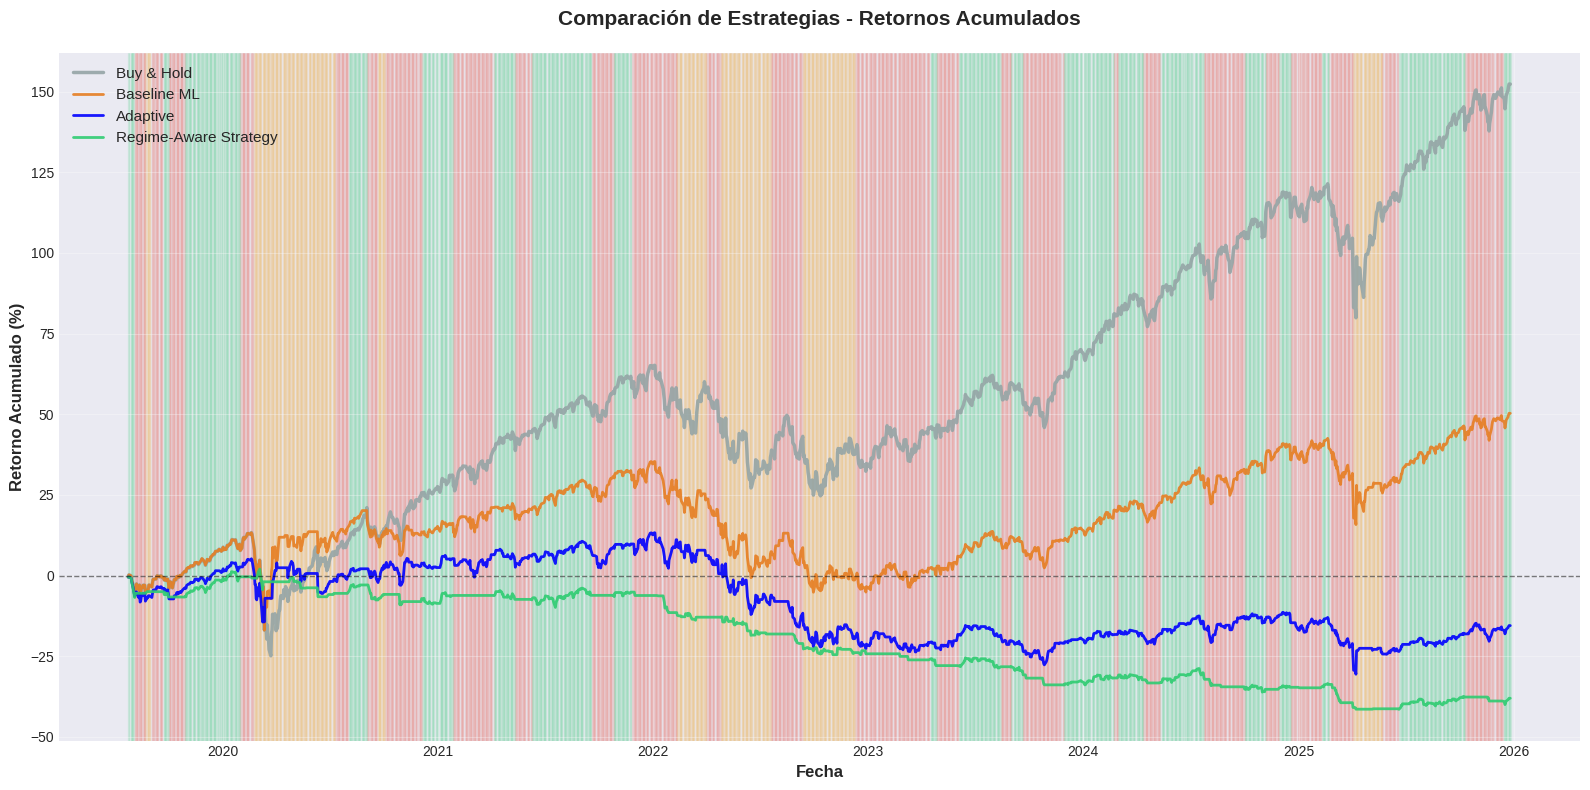

In [9]:
def plot_cumulative_returns(strategies_results, df_test):
    """
    Grafica retornos acumulados de todas las estrategias
    """
    fig, ax = plt.subplots(figsize=(16, 8))

    colors = {
        'Buy & Hold': '#95A5A6',
        'Baseline ML': '#E67E22',
        'Adaptive Strategy': '#3498DB',
        'Regime-Aware Strategy': '#2ECC71'
    }

    linewidths = {
        'Buy & Hold': 2.5,
        'Baseline ML': 2,
        'Adaptive Strategy': 2.5,
        'Regime-Aware Strategy': 2
    }

    # Plot cada estrategia
    for results in strategies_results:
        name = results['strategy_name']
        cum_ret = results['cumulative_returns']

        ax.plot(cum_ret.index, (cum_ret - 1) * 100,
                label=name,
                linewidth=linewidths.get(name, 2),
                color=colors.get(name, 'blue'),
                alpha=0.9)

    # Marcar regímenes de fondo
    regime_colors = {
        'Bull Market': '#2ECC71',
        'Bear Market': '#E74C3C',
        'High Volatility': '#F39C12'
    }

    for regime, color in regime_colors.items():
        regime_mask = df_test['Regime_Name'] == regime
        regime_periods = df_test[regime_mask].index

        if len(regime_periods) > 0:
            for date in regime_periods:
                ax.axvspan(date, date + pd.Timedelta(days=1),
                          alpha=0.1, color=color, zorder=0)

    # Configuración
    ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax.set_ylabel('Retorno Acumulado (%)', fontsize=12, fontweight='bold')
    ax.set_title('Comparación de Estrategias - Retornos Acumulados',
                 fontsize=15, fontweight='bold', pad=20)
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    plt.tight_layout()
    plt.savefig('04_cumulative_returns.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '04_cumulative_returns.png'")
    plt.show()

# Generar visualización
all_strategies = [bh_results, ml_results, adaptive_results, regime_aware_results]
plot_cumulative_returns(all_strategies, df_test)

### 4.4.2 Drawdown Analysis

✓ Gráfico guardado: '04_drawdowns.png'


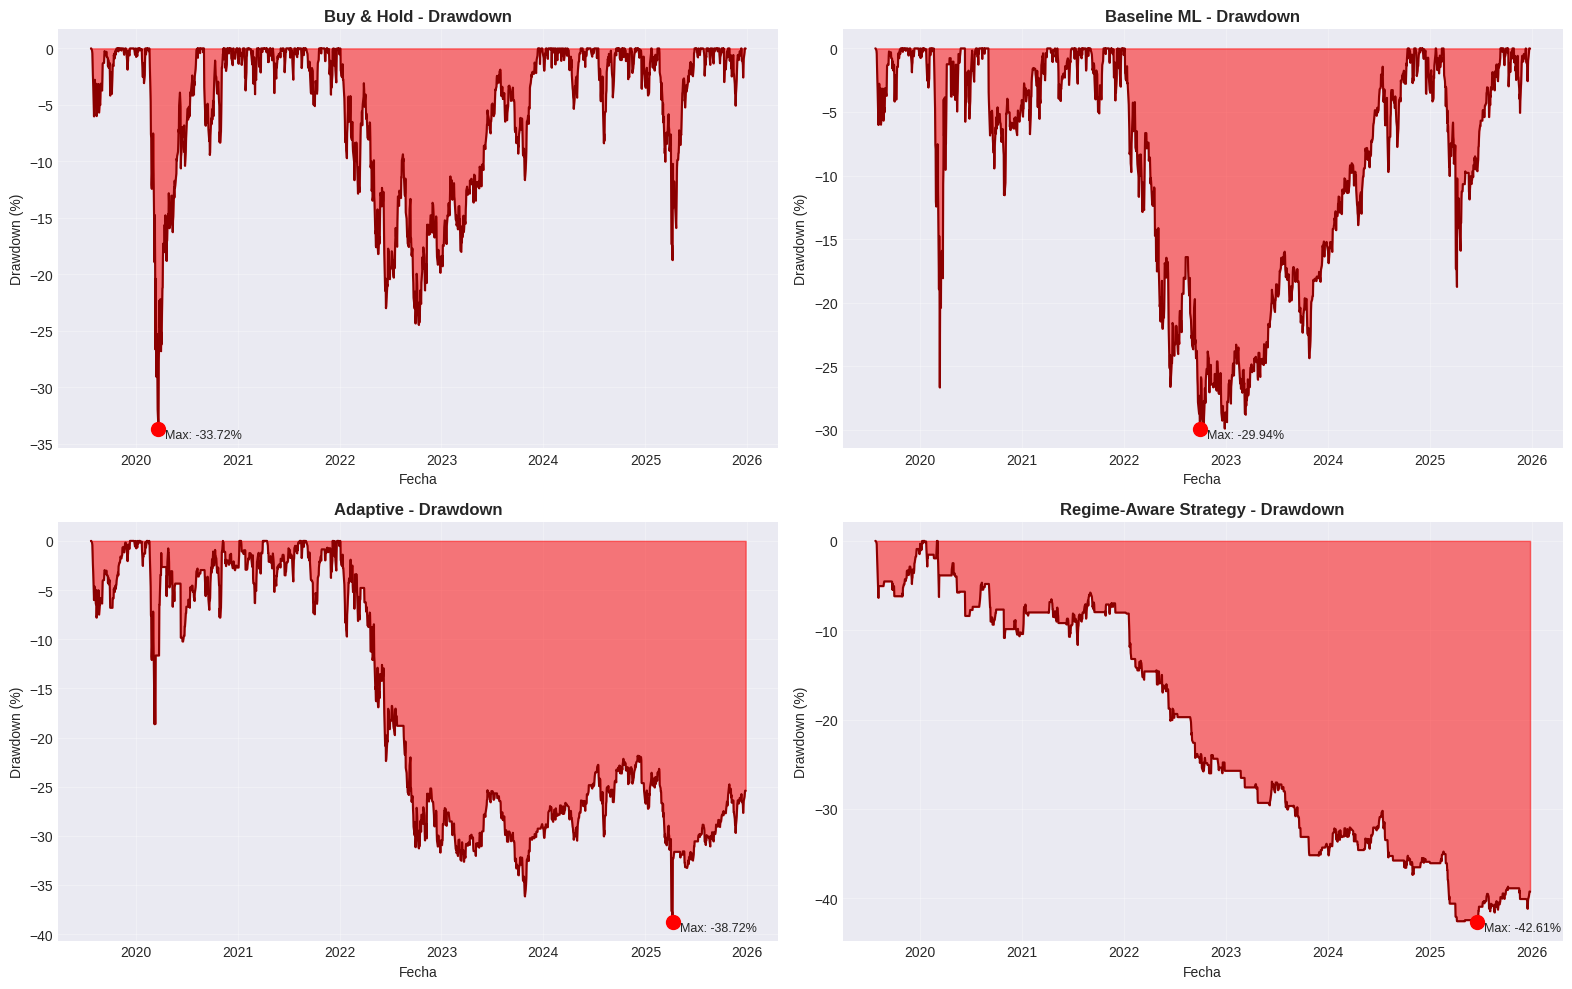

In [10]:
def plot_drawdowns(strategies_results):
    """
    Grafica drawdowns de cada estrategia
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for idx, results in enumerate(strategies_results):
        name = results['strategy_name']
        cum_ret = results['cumulative_returns']

        # Calcular drawdown
        running_max = cum_ret.expanding().max()
        drawdown = (cum_ret - running_max) / running_max * 100

        # Plot
        axes[idx].fill_between(drawdown.index, drawdown, 0,
                               alpha=0.5, color='red', label='Drawdown')
        axes[idx].plot(drawdown.index, drawdown,
                      color='darkred', linewidth=1.5)

        axes[idx].set_title(f'{name} - Drawdown',
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Drawdown (%)', fontsize=10)
        axes[idx].set_xlabel('Fecha', fontsize=10)
        axes[idx].grid(True, alpha=0.3)

        # Marcar max drawdown
        max_dd = drawdown.min()
        max_dd_date = drawdown.idxmin()
        axes[idx].plot(max_dd_date, max_dd, 'ro', markersize=10)
        axes[idx].text(max_dd_date, max_dd, f'  Max: {max_dd:.2f}%',
                      fontsize=9, verticalalignment='top')

    plt.tight_layout()
    plt.savefig('04_drawdowns.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '04_drawdowns.png'")
    plt.show()

# Generar drawdowns
plot_drawdowns(all_strategies)

### 4.4.3 Comparación de Métricas (Barras)

✓ Gráfico guardado: '04_metrics_comparison.png'


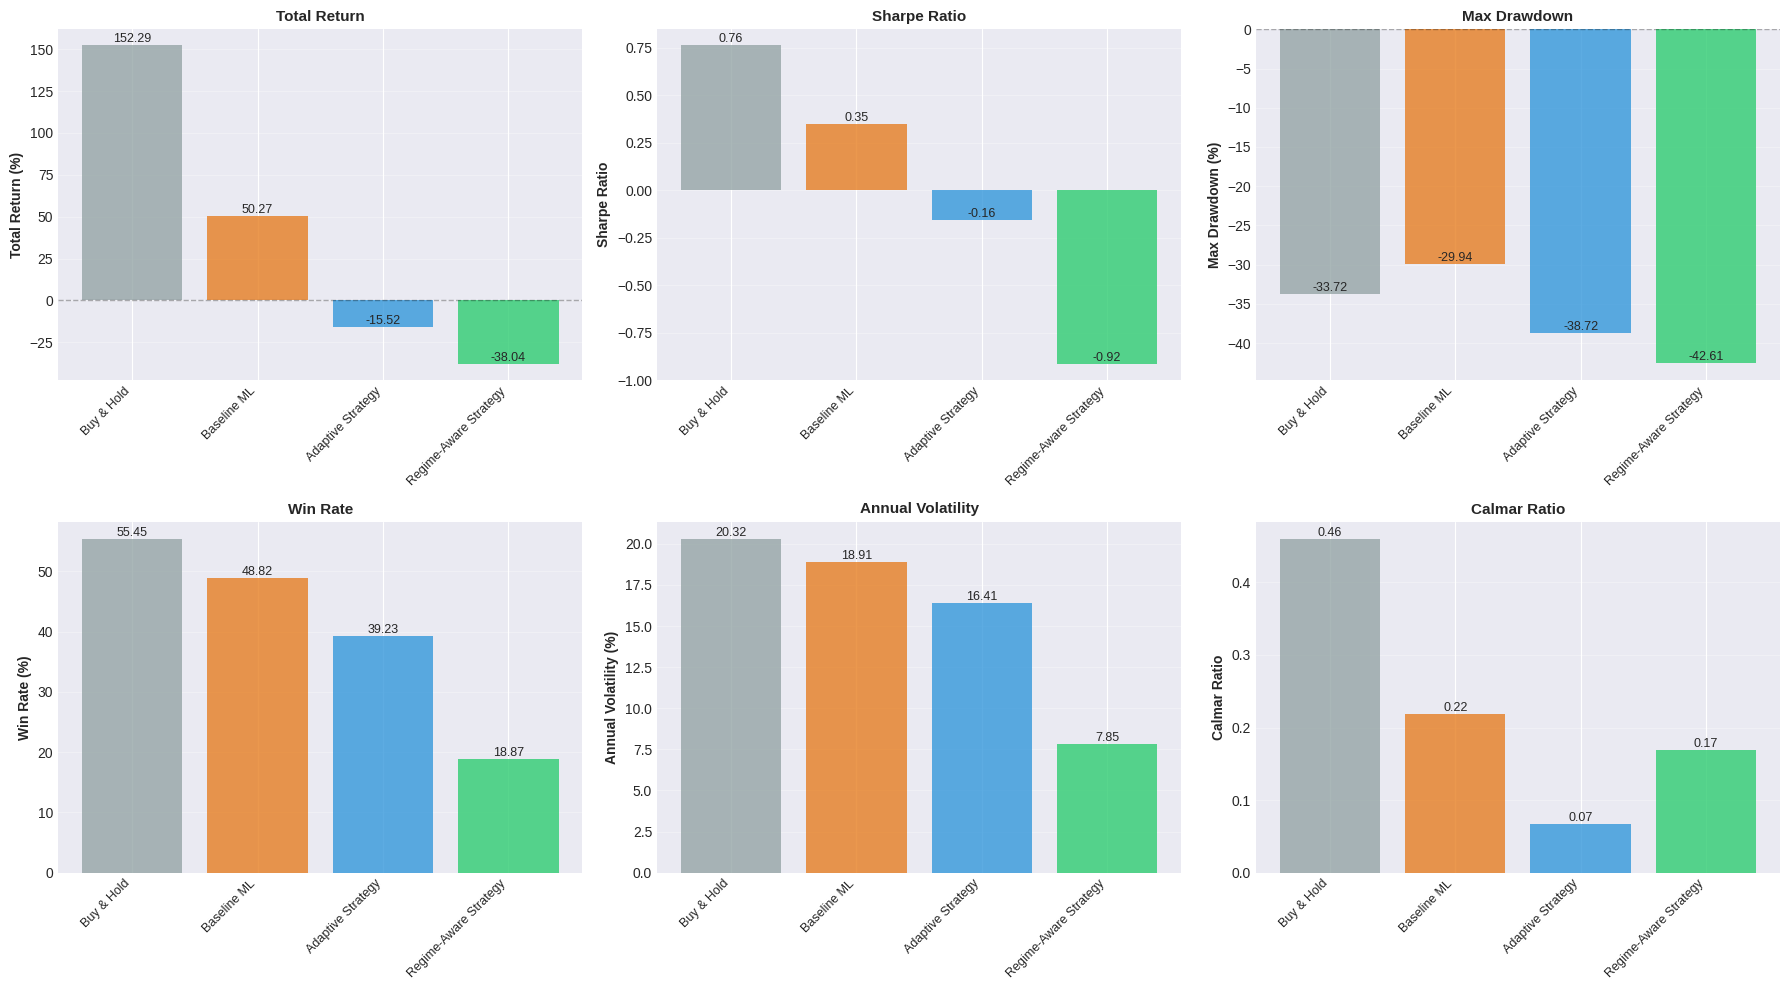

In [11]:
def plot_metrics_comparison(metrics_df):
    """
    Visualiza comparación de métricas clave
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics_to_plot = [
        ('Total Return', 'Total Return', '%', 100),
        ('Sharpe Ratio', 'Sharpe Ratio', '', 1),
        ('Max Drawdown', 'Max Drawdown', '%', 100),
        ('Win Rate', 'Win Rate', '%', 100),
        ('Annual Volatility', 'Annual Volatility', '%', 100),
        ('Calmar Ratio', 'Calmar Ratio', '', 1)
    ]

    colors = ['#95A5A6', '#E67E22', '#3498DB', '#2ECC71']

    for idx, (metric, title, unit, multiplier) in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]

        values = metrics_df[metric] * multiplier
        bars = ax.bar(range(len(metrics_df)), values, color=colors, alpha=0.8)

        ax.set_xticks(range(len(metrics_df)))
        ax.set_xticklabels(metrics_df['Strategy'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel(f'{title} ({unit})' if unit else title, fontsize=10, fontweight='bold')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Agregar valores sobre barras
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}',
                   ha='center', va='bottom', fontsize=9)

        # Línea en cero para métricas que pueden ser negativas
        if metric in ['Total Return', 'Max Drawdown']:
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)

    plt.tight_layout()
    plt.savefig('04_metrics_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '04_metrics_comparison.png'")
    plt.show()

# Visualizar comparación
plot_metrics_comparison(metrics_df)

### 4.4.4 Performance por Régimen

In [12]:
def analyze_performance_by_regime(df_test, strategies_results):
    """
    Analiza performance de cada estrategia por régimen
    """
    print("="*90)
    print("📊 PERFORMANCE POR RÉGIMEN")
    print("="*90)

    regime_performance = []

    for regime in df_test['Regime_Name'].unique():
        regime_data = df_test[df_test['Regime_Name'] == regime]

        for results in strategies_results:
            name = results['strategy_name']
            returns = results['daily_returns'].loc[regime_data.index]

            # Métricas
            total_ret = (1 + returns).prod() - 1
            sharpe = (returns.mean() / returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
            win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0

            regime_performance.append({
                'Regime': regime,
                'Strategy': name,
                'Days': len(returns),
                'Total Return': total_ret,
                'Sharpe': sharpe,
                'Win Rate': win_rate
            })

    perf_df = pd.DataFrame(regime_performance)

    # Pivot para mejor visualización
    for metric in ['Total Return', 'Sharpe', 'Win Rate']:
        print(f"\n📈 {metric} por Régimen:")
        pivot = perf_df.pivot(index='Strategy', columns='Regime', values=metric)

        if metric == 'Total Return' or metric == 'Win Rate':
            print(pivot.apply(lambda x: x * 100).to_string(float_format=lambda x: f"{x:>7.2f}%"))
        else:
            print(pivot.to_string(float_format=lambda x: f"{x:>7.3f}"))

    print("\n" + "="*90)

    return perf_df

# Analizar performance por régimen
regime_perf = analyze_performance_by_regime(df_test, all_strategies)

📊 PERFORMANCE POR RÉGIMEN

📈 Total Return por Régimen:
Regime                 Bear Market  Bull Market  High Volatility
Strategy                                                        
Adaptive                   -11.20%       22.61%          -22.41%
Baseline ML                 17.53%       63.32%          -21.71%
Buy & Hold                  49.99%       90.35%          -11.63%
Regime-Aware Strategy      -38.23%       18.99%          -15.70%

📈 Sharpe por Régimen:
Regime                 Bear Market  Bull Market  High Volatility
Strategy                                                        
Adaptive                    -0.224        1.101           -0.590
Baseline ML                  0.435        2.367           -0.434
Buy & Hold                   0.949        2.984           -0.088
Regime-Aware Strategy       -2.804        0.903           -1.388

📈 Win Rate por Régimen:
Regime                 Bear Market  Bull Market  High Volatility
Strategy                                            

## 4.5 Análisis de Significancia Estadística
### 4.5.1 Métricas Estadísticas

In [13]:
from scipy import stats

def test_strategy_significance(strategy1_returns, strategy2_returns, name1='Strategy 1', name2='Strategy 2'):
    """
    Test t-student para diferencia de medias entre estrategias
    """
    # T-test
    t_stat, p_value = stats.ttest_ind(strategy1_returns, strategy2_returns)

    # Diferencia de medias
    mean_diff = strategy1_returns.mean() - strategy2_returns.mean()

    print(f"\n🔬 Test de Significancia: {name1} vs {name2}")
    print(f"   Diferencia de medias: {mean_diff:.6f} ({mean_diff*252*100:.2f}% anualizado)")
    print(f"   T-statistic: {t_stat:.4f}")
    print(f"   P-value: {p_value:.4f}")

    if p_value < 0.05:
        print(f"   ✅ Diferencia SIGNIFICATIVA (p < 0.05)")
    else:
        print(f"   ⚠️  Diferencia NO significativa (p >= 0.05)")

    return t_stat, p_value

# Comparaciones clave
print("="*90)
print("📊 ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA")
print("="*90)

test_strategy_significance(adaptive_results['daily_returns'],
                          bh_results['daily_returns'],
                          'Adaptive Strategy', 'Buy & Hold')

test_strategy_significance(regime_aware_results['daily_returns'],
                          bh_results['daily_returns'],
                          'Regime-Aware Strategy', 'Buy & Hold')

test_strategy_significance(adaptive_results['daily_returns'],
                          ml_results['daily_returns'],
                          'Adaptive Strategy', 'Baseline ML')

print("\n" + "="*90)

📊 ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA

🔬 Test de Significancia: Adaptive Strategy vs Buy & Hold
   Diferencia de medias: -0.000706 (-17.79% anualizado)
   T-statistic: -1.7246
   P-value: 0.0847
   ⚠️  Diferencia NO significativa (p >= 0.05)

🔬 Test de Significancia: Regime-Aware Strategy vs Buy & Hold
   Diferencia de medias: -0.000939 (-23.66% anualizado)
   T-statistic: -2.7502
   P-value: 0.0060
   ✅ Diferencia SIGNIFICATIVA (p < 0.05)

🔬 Test de Significancia: Adaptive Strategy vs Baseline ML
   Diferencia de medias: -0.000374 (-9.42% anualizado)
   T-statistic: -0.9529
   P-value: 0.3407
   ⚠️  Diferencia NO significativa (p >= 0.05)



### 4.5.2 ¿Por qué falló?.

In [14]:
def analyze_missed_opportunities(df_test, strategy_returns, bh_returns):
    """
    Analiza cuándo el sistema falló críticamente
    """
    print("="*70)
    print("🔍 ANÁLISIS DE OPORTUNIDADES PERDIDAS")
    print("="*70)

    # Identificar los mejores días del mercado
    top_days = df_test.nlargest(20, 'Returns')

    print(f"\n📈 Top 20 mejores días del mercado:")
    print(f"  Retorno acumulado: {top_days['Returns'].sum()*100:.2f}%")

    # ¿Cuántos capturó la estrategia?
    strategy_signals = strategy_returns.loc[top_days.index] != 0
    captured = strategy_signals.sum()

    print(f"\n  Estrategia capturó: {captured} / 20 ({captured/20*100:.0f}%)")
    print(f"  Retorno perdido: {top_days[~strategy_signals]['Returns'].sum()*100:.2f}%")

    # Peores días
    worst_days = df_test.nsmallest(20, 'Returns')
    print(f"\n📉 Top 20 peores días del mercado:")
    print(f"  Pérdida acumulada: {worst_days['Returns'].sum()*100:.2f}%")

    protected = (strategy_returns.loc[worst_days.index] == 0).sum()
    print(f"  Estrategia evitó: {protected} / 20 ({protected/20*100:.0f}%)")

    print("="*70)

# Ejecutar análisis
analyze_missed_opportunities(df_test,
                            adaptive_results['daily_returns'],
                            bh_results['daily_returns'])

🔍 ANÁLISIS DE OPORTUNIDADES PERDIDAS

📈 Top 20 mejores días del mercado:
  Retorno acumulado: 96.35%

  Estrategia capturó: 12 / 20 (60%)
  Retorno perdido: 36.98%

📉 Top 20 peores días del mercado:
  Pérdida acumulada: -102.16%
  Estrategia evitó: 7 / 20 (35%)


## 4.6 Resumen Ejecutivo

In [15]:
def generate_executive_summary(metrics_df, df_test):
    """
    Genera resumen ejecutivo para el paper
    """
    print("\n" + "="*90)
    print("📋 RESUMEN EJECUTIVO - BACKTESTING RESULTS")
    print("="*90)

    # Mejor estrategia por métrica
    best_return = metrics_df.loc[metrics_df['Total Return'].idxmax()]
    best_sharpe = metrics_df.loc[metrics_df['Sharpe Ratio'].idxmax()]
    best_drawdown = metrics_df.loc[metrics_df['Max Drawdown'].idxmax()]  # Menos negativo

    print(f"\n🏆 MEJORES ESTRATEGIAS POR MÉTRICA:")
    print(f"   Mayor retorno:      {best_return['Strategy']:<25} ({best_return['Total Return']*100:>6.2f}%)")
    print(f"   Mayor Sharpe:       {best_sharpe['Strategy']:<25} ({best_sharpe['Sharpe Ratio']:>6.3f})")
    print(f"   Menor Drawdown:     {best_drawdown['Strategy']:<25} ({best_drawdown['Max Drawdown']*100:>6.2f}%)")

    # Comparación vs Buy & Hold
    bh_metrics = metrics_df[metrics_df['Strategy'] == 'Buy & Hold'].iloc[0]
    adaptive_metrics = metrics_df[metrics_df['Strategy'] == 'Adaptive Strategy'].iloc[0]

    print(f"\n📊 ADAPTIVE STRATEGY VS BUY & HOLD:")
    print(f"   Retorno:       {adaptive_metrics['Total Return']*100:>6.2f}% vs {bh_metrics['Total Return']*100:>6.2f}% " +
          f"({(adaptive_metrics['Total Return'] - bh_metrics['Total Return'])*100:+.2f}%)")
    print(f"   Sharpe Ratio:  {adaptive_metrics['Sharpe Ratio']:>6.3f} vs {bh_metrics['Sharpe Ratio']:>6.3f} " +
          f"({adaptive_metrics['Sharpe Ratio'] - bh_metrics['Sharpe Ratio']:+.3f})")
    print(f"   Max Drawdown:  {adaptive_metrics['Max Drawdown']*100:>6.2f}% vs {bh_metrics['Max Drawdown']*100:>6.2f}% " +
          f"({(adaptive_metrics['Max Drawdown'] - bh_metrics['Max Drawdown'])*100:+.2f}%)")

    # Periodo de test
    test_duration_days = (df_test.index[-1] - df_test.index[0]).days
    test_duration_years = test_duration_days / 365.25

    print(f"\n📅 PERIODO DE EVALUACIÓN:")
    print(f"   Fechas:        {df_test.index[0].date()} → {df_test.index[-1].date()}")
    print(f"   Duración:      {test_duration_days} días ({test_duration_years:.2f} años)")
    print(f"   Días trading:  {len(df_test)}")

    print("\n" + "="*90)

# Generar resumen
generate_executive_summary(metrics_df, df_test)


📋 RESUMEN EJECUTIVO - BACKTESTING RESULTS

🏆 MEJORES ESTRATEGIAS POR MÉTRICA:
   Mayor retorno:      Buy & Hold                (152.29%)
   Mayor Sharpe:       Buy & Hold                ( 0.764)
   Menor Drawdown:     Baseline ML               (-29.94%)

📊 ADAPTIVE STRATEGY VS BUY & HOLD:
   Retorno:       -15.52% vs 152.29% (-167.81%)
   Sharpe Ratio:  -0.158 vs  0.764 (-0.922)
   Max Drawdown:  -38.72% vs -33.72% (-5.00%)

📅 PERIODO DE EVALUACIÓN:
   Fechas:        2019-07-25 → 2025-12-26
   Duración:      2346 días (6.42 años)
   Días trading:  1616



## 4.7 Guardar Resultados Finales

In [16]:
# Guardar métricas
metrics_df.to_csv('backtesting_metrics.csv', index=False)
print("✓ Métricas guardadas en 'backtesting_metrics.csv'")

# Guardar retornos de todas las estrategias
returns_df = pd.DataFrame({
    'Date': df_test.index,
    'Buy_Hold': bh_results['daily_returns'].values,
    'Baseline_ML': ml_results['daily_returns'].values,
    'Adaptive': adaptive_results['daily_returns'].values,
    'Regime_Aware': regime_aware_results['daily_returns'].values
})
returns_df.to_csv('strategy_returns.csv', index=False)
print("✓ Retornos diarios guardados en 'strategy_returns.csv'")

# Guardar performance por régimen
regime_perf.to_csv('performance_by_regime.csv', index=False)
print("✓ Performance por régimen guardado en 'performance_by_regime.csv'")

✓ Métricas guardadas en 'backtesting_metrics.csv'
✓ Retornos diarios guardados en 'strategy_returns.csv'
✓ Performance por régimen guardado en 'performance_by_regime.csv'
